Двойной математический маятник

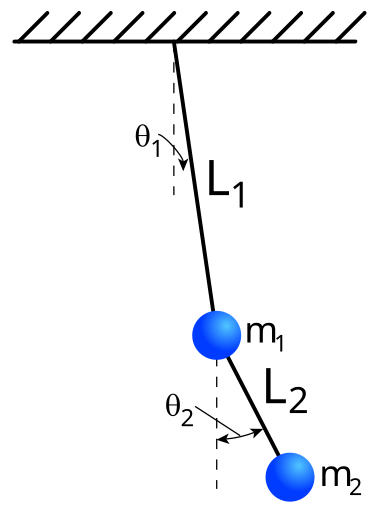

Начало декартовой системы поместим в точку подвеса первого звена. Относительно этой системы координат центры масс:

$x_1 = L_1*sin(\theta_1)$

$y_1=-L_1*cos(\theta_1)$

$x_2 = L_1*sin(\theta_1)+L_2*sin(\theta_2)$

$y_2 = -L_1*cos(\theta_1)-L_2*cos(\theta_2)$

$\dot{x_1}=L_1\dot{\theta_1}cos(\theta_1)$

$\dot{y_1}=L_1\dot{\theta_1}sin(\theta_1)$

$\dot{x_2}=L_1\dot{\theta_1}cos(\theta_1)+L_2\dot{\theta_2}cos(\theta_2)$

$\dot{y_2}=L_1\dot{\theta_1}sin(\theta_1)+L_2\dot{\theta_2}sin(\theta_2)$


Потенциальная энергия:

$П = -mgL_1*cos(\theta_1)-mg(L_1*cos(\theta_1)+L_2*cos(\theta_2))$

Функция Лагранжа:

$L = T - П = \frac{1}{2}m_1L_1^2\dot{\theta_1}^2+\frac{1}{2}m_2(L_1^2\dot{\theta_1}^2+L_2^2\dot{\theta_2}^2+2L_1L_2\dot{\theta_1}^2\dot{\theta_2}^2*cos(\theta_1-\theta_2))+m_1gL_1*cos(\theta_1)+m_2g(L_1*cos(\theta_1)+L_2*cos(\theta_2))$

Уравнения Лагранжа для консервативной системы:

$\frac{d}{dt}\frac{\partial{L}}{\partial{\dot{\theta_1}}}-\frac{\partial{L}}{\partial{\theta_1}}=0$

$\frac{d}{dt}\frac{\partial{L}}{\partial{\dot{\theta_2}}}-\frac{\partial{L}}{\partial{\theta_2}}=0$

Уравнения примут вид:

$(m_1+m_2)L_1^2\ddot{\theta_1}+m_2\ddot{\theta_2}L_1L_2*cos(\theta_1-\theta_2)-m_2\dot{\theta_2}^2L_1L_2*sin(\theta_2-\theta_1)+(m_1+m_2)gL_1*sin(\theta_1)=0$

$m_2L_2^2\ddot{\theta_2}+m_2\ddot{\theta_1}L_1L_2*cos(\theta_1-\theta_2)+m_2\dot{\theta_1}^2L_1L_2*sin(\theta_2-\theta_1)+m_2gL_2*sin(\theta_2)=0$

$\ddot{\theta_1} = -\frac{g*sin(\theta_1)m_1+sin(\theta_1-\theta_2)m_2*(g*cos(\theta_2)+cos(\theta_1-\theta_2)L_1\dot{\theta_1}^2+L_2\dot{\theta_2}^2)}{L_2(m_1 + m_2*sin^2(\theta_1-\theta_2))}$



$\ddot{\theta_2} =sin(\theta_1-\theta_2)\frac {m_1(g*cos(\theta_1)+L_1\dot{\theta_1}^2)+m_2(g*cos(\theta_1)+L_1*\dot{\theta_1}^2+cos(\theta_1-\theta_2)*L_2*\dot{\theta_2}^2)}  {L_2(m_1 + m_2*sin^2(\theta_1-\theta_2))}$

$z_1 = \dot{\theta_1}$

$z_2 = \dot{\theta_2}$

In [ ]:
#Импорт зависимостей
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, MovieWriter
from IPython.display import HTML

In [ ]:
#Параметры
m1 = 1.0
m2 = 1.0
L1 = 1.0
L2 = 1.0
g = 9.81

# Параметры моделирования
T = 20
h = 0.05
theta1_0 = np.pi / 2
theta2_0 = np.pi / 2
omega1_0 = 0.0
omega2_0 = 0.0

In [ ]:
#Функции для выражения вторых производных углов отклонения
def equations(t, state):
    theta1, omega1, theta2, omega2 = state
    delta_theta = theta1 - theta2
    cos_delta = np.cos(delta_theta)
    sin_delta = np.sin(delta_theta)
    denominator = m1 + m2 * sin_delta**2
    alpha1 = (m2 * g * np.sin(theta2) * cos_delta - 
              m2 * sin_delta * (L1 * omega1**2 * cos_delta + L2 * omega2**2) - 
              (m1 + m2) * g * np.sin(theta1)) / (L1 * denominator)
    alpha2 = ((m1 + m2) * (L1 * omega1**2 * sin_delta - 
                           g * np.sin(theta2) + 
                           g * np.sin(theta1) * cos_delta) + 
              m2 * L2 * omega2**2 * sin_delta * cos_delta) / (L2 * denominator)
    return np.array([omega1, alpha1, omega2, alpha2])

In [ ]:
#Метод Рунге-Кутты RK4
def rk4_step(func, t, state, h):
    k1 = func(t, state)
    k2 = func(t + h/2, state + h/2 * k1)
    k3 = func(t + h/2, state + h/2 * k2)
    k4 = func(t + h, state + h * k3)
    return state + h * (k1 + 2*k2 + 2*k3 + k4) / 6

In [ ]:
#Численное решение
def simulate_double_pendulum(theta1_0, omega1_0, theta2_0, omega2_0, T, h):
    t = np.arange(0, T, h)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0])
    states = np.zeros((len(t), 4))
    for i in range(len(t)):
        states[i] = state
        state = rk4_step(equations, t[i], state, h)
    return t, states

In [ ]:
# Запуск моделирования
t, states = simulate_double_pendulum(theta1_0, omega1_0, theta2_0, omega2_0, T, h)
theta1 = states[:, 0]
theta2 = states[:, 2]
omega1 = states[:, 1]
omega2 = states[:, 3]

# Графики углов и угловых скоростей
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(t, theta1, label=f'θ₁')
ax1.plot(t, theta2, label=f'θ₂')
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('Угол (рад)')
ax1.set_title('Изменение углов двойного маятника')
ax1.legend()
ax1.grid()

ax2.plot(t, omega1, label='ω₁')
ax2.plot(t, omega2, label='ω₂')
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Угловая скорость (рад/с)')
ax2.set_title('Изменение угловых скоростей двойного маятника')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Анимация движения маятника
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
line, = ax.plot([], [], 'o-', lw=2)
time_text = ax.text(0.05, 0.95, '', transform=ax.transAxes)

def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text

def animate(i):
    x1 = L1 * np.sin(theta1[i])
    y1 = -L1 * np.cos(theta1[i])
    x2 = x1 + L2 * np.sin(theta2[i])
    y2 = y1 - L2 * np.cos(theta2[i])
    line.set_data([0, x1, x2], [0, y1, y2])
    time_text.set_text(f'Время = {t[i]:.1f} с')
    return line, time_text

ani = FuncAnimation(fig, animate, frames=len(t), init_func=init, blit=True, interval=h*1000)

HTML(ani.to_jshtml())

In [ ]:
#Чувствительность к начальным условиям
theta1_0_small1 = np.pi / 2
theta2_0_small1 = np.pi / 2
theta1_0_small2 = np.pi / 2 + 0.001
theta2_0_small2 = np.pi / 2 + 0.001

t1, states1 = simulate_double_pendulum(theta1_0_small1, omega1_0, theta2_0_small1, omega2_0, T, h)
t2, states2 = simulate_double_pendulum(theta1_0_small2, omega1_0, theta2_0_small2, omega2_0, T, h)

theta1_1 = states1[:, 0]
theta2_1 = states1[:, 2]
theta1_2 = states2[:, 0]
theta2_2 = states2[:, 2]

# График различия траекторий
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t1, theta1_1, label='θ₁ (исходный)')
plt.plot(t2, theta1_2, label='θ₁ (измененный)')
plt.xlabel('Время (с)')
plt.ylabel('Угол (рад)')
plt.title('Сравнение θ₁')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t1, theta2_1, label='θ₂ (исходный)')
plt.plot(t2, theta2_2, label='θ₂ (измененный)')
plt.xlabel('Время (с)')
plt.ylabel('Угол (рад)')
plt.title('Сравнение θ₂')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# График разницы углов
diff_theta1 = np.abs(theta1_1 - theta1_2)
diff_theta2 = np.abs(theta2_1 - theta2_2)

plt.figure(figsize=(10, 5))
plt.plot(t1, diff_theta1, label='Разница θ₁')
plt.plot(t1, diff_theta2, label='Разница θ₂')
plt.xlabel('Время (с)')
plt.ylabel('Разница углов (рад)')
plt.title('Чувствительность к начальным условиям')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Функция кинетической энергии
def compute_kinetic_energy(state):
    theta1, omega1, theta2, omega2 = state
    KE1 = 0.5 * m1 * (L1 * omega1)**2
    v2x = L1 * omega1 * np.cos(theta1) + L2 * omega2 * np.cos(theta2)
    v2y = L1 * omega1 * np.sin(theta1) + L2 * omega2 * np.sin(theta2)
    KE2 = 0.5 * m2 * (v2x**2 + v2y**2)
    return KE1 + KE2

In [ ]:
#Цветовая карта кинетической энергии
n_points = 20
theta1_0_range = np.linspace(-np.pi, np.pi, n_points)
theta2_0_range = np.linspace(-np.pi, np.pi, n_points)
Theta1_0, Theta2_0 = np.meshgrid(theta1_0_range, theta2_0_range)

T_short = 10
t_short = np.arange(0, T_short, h)
n_frames = len(t_short)

kinetic_energy = np.zeros((n_points, n_points, n_frames))

for i in range(n_points):
    for j in range(n_points):
        t, states = simulate_double_pendulum(Theta1_0[i, j], omega1_0, Theta2_0[i, j], omega2_0, T_short, h)
        for k in range(min(n_frames, len(t))):
            KE = compute_kinetic_energy(states[k])
            kinetic_energy[i, j, k] = KE

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(kinetic_energy[:, :, 0], extent=[-np.pi, np.pi, -np.pi, np.pi], 
               origin='lower', cmap='hot', vmin=0, vmax=np.max(kinetic_energy))
plt.colorbar(im, label='Кинетическая энергия (Дж)')
ax.set_xlabel('Начальный угол θ₁ (рад)')
ax.set_ylabel('Начальный угол θ₂ (рад)')
title = ax.set_title('Кинетическая энергия в момент времени t = 0.0 с')

def update_energy(frame):
    im.set_array(kinetic_energy[:, :, frame])
    title.set_text(f'Кинетическая энергия в момент времени t = {t_short[frame]:.1f} с')
    return im, title

ani_energy = FuncAnimation(fig, update_energy, frames=n_frames, interval=100, blit=True)
HTML(ani_energy.to_jshtml())